# Main analyses - Indicium AI's Data Analytics Certification

In [ ]:
#Etapas desse notebook:
    #Data quality -> Validar a qualidade e integridade dos dados
    #Data preparation -> Ajustar o que for necessário dos datasets de acordo com a análise do data quality preparando os dados para o EDA
    #EDA + insights -> Gerar insights que atendam principalmente:
        #Diretora comercial  (Camila Diniz): o objetivo da área comercial é aumentar a quantidade de transações por cliente, mantendo-os ativos e diminuindo o risco de churn
        #CEO: ele quer avaliar e saber onde precisa investir esforço no próximo trimestre
    #KPIs summary -> Para construção do mockup/dashboard
    #Mockup

## Libraries

In [3]:
#Importando as bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append("../")

## Variables & functions

In [4]:
#Variáveis globais
from src.variables import (
    OLD_DATASET_DIR,
    NEW_DATASET_DIR
)

In [5]:
#Funções globais
import src.functions as func

#Funções exclusivas para a análise de valores monetários
import src.monetary_valuations as monval

#Funções exclusivas para a preparação dos dados (Data quality)
import src.preparation_functions as prep

#Funções exclusivas para a análise dos dados (EDA)
import src.analytics_functions as analytic

## Data quality

### Dataset overview

In [6]:
#Função para mostrar as colunas dos arquivos CSV na pasta "Old_Dataset" - Overview dos datasets originais
func.show_columns(OLD_DATASET_DIR)

Arquivos encontrados: 7

Arquivo: agencias.csv
Quantidade de colunas: 7
------------------------------------------------------------
- cod_agencia
- nome
- endereco
- cidade
- uf
- data_abertura
- tipo_agencia

Arquivo: clientes.csv
Quantidade de colunas: 10
------------------------------------------------------------
- cod_cliente
- primeiro_nome
- ultimo_nome
- email
- tipo_cliente
- data_inclusao
- cpfcnpj
- data_nascimento
- endereco
- cep

Arquivo: colaborador_agencia.csv
Quantidade de colunas: 2
------------------------------------------------------------
- cod_colaborador
- cod_agencia

Arquivo: colaboradores.csv
Quantidade de colunas: 8
------------------------------------------------------------
- cod_colaborador
- primeiro_nome
- ultimo_nome
- email
- cpf
- data_nascimento
- endereco
- cep

Arquivo: contas.csv
Quantidade de colunas: 9
------------------------------------------------------------
- num_conta
- cod_cliente
- cod_agencia
- cod_colaborador
- tipo_conta
- data_aber

### Exploration of dataset - Dimensional

In [7]:
#Função para carregar todos os arquivos CSVs da pasta "Old_Dataset" e armazenar em um dicionário para iniciarmos a análise da qualidade dos dados
old_datasets = func.load_csv_files(OLD_DATASET_DIR)

#Dimensão das bases
for name, df in old_datasets.items():
    print(f"{name}: {df.shape}")

agencias: (10, 7)
clientes: (998, 10)
colaborador_agencia: (100, 2)
colaboradores: (100, 8)
contas: (999, 9)
propostas_credito: (2000, 12)
transacoes: (71999, 5)


In [8]:
#Observações:
    #998 clientes -> Valor base
    #999 contas -> Necessário verificar, pois potencialmente existe um cliente com mais de uma conta, ou uma conta sem correspondência
    #2000 propostas de crédito -> Um cliente pode ter várias propostas
    #71999 transações -> Várias transações para uma mesma conta são observadas

### Exploration of dataset - Collumns types

In [9]:
#Função para inspecionar os tipos dos dados dos dicionários
data_types = func.inspect_data_types(old_datasets)

for dataset_name, df_types in data_types.items():
    print(f"\n{'=' * 50}")
    print(dataset_name)
    print(f"{'=' * 50}")
    print(df_types.to_string(index=False))


agencias
       column data_type
  cod_agencia     int64
         nome       str
     endereco       str
       cidade       str
           uf       str
data_abertura       str
 tipo_agencia       str

clientes
         column data_type
    cod_cliente     int64
  primeiro_nome       str
    ultimo_nome       str
          email       str
   tipo_cliente       str
  data_inclusao       str
        cpfcnpj       str
data_nascimento       str
       endereco       str
            cep       str

colaborador_agencia
         column data_type
cod_colaborador     int64
    cod_agencia     int64

colaboradores
         column data_type
cod_colaborador     int64
  primeiro_nome       str
    ultimo_nome       str
          email       str
            cpf       str
data_nascimento       str
       endereco       str
            cep       str

contas
                column data_type
             num_conta     int64
           cod_cliente     int64
           cod_agencia     int64
       cod_col

In [10]:
#Observações:
    #Datas em str -> Será necessário tratar para datetime
    #Códigos/números (ids) em int64 -> Vale a pena verificar se não existem códigos com zeros à esquerda, que podem ser perdidos ao converter para int64
    #Valores monetários em float64 -> Decimais importam
    #Quantidade de parcelas/carência em int64
    #Taxa de juros em float64 -> Decimais importam

In [11]:
#Analisando o cabeçalho dos datasets para verificar se os dados sofreram mudança quando foram convertidos em dicionários
for dataset_name, df in old_datasets.items():
    print(f"\n{dataset_name}")
    print(df.head().to_string(index=False))


agencias
 cod_agencia             nome                                                            endereco    cidade uf data_abertura tipo_agencia
           7  Agência Digital     Av. Paulista, 1436 - Cerqueira César, São Paulo - SP, 01310-916 São Paulo SP    2015-08-01      Digital
           1   Agência Matriz     Av. Paulista, 1436 - Cerqueira César, São Paulo - SP, 01310-916 São Paulo SP    2010-01-01       Física
           2  Agência Tatuapé       Praça Sílvio Romero, 158 - Tatuapé, São Paulo - SP, 03323-000 São Paulo SP    2010-06-14       Física
           3 Agência Campinas  Av. Francisco Glicério, 895 - Vila Lidia, Campinas - SP, 13012-000  Campinas SP    2012-03-04       Física
           4   Agência Osasco Av. Antônio Carlos Costa, 1000 - Bela Vista, Osasco - SP, 06053-014    Osasco SP    2013-11-06       Física

clientes
 cod_cliente primeiro_nome ultimo_nome                        email tipo_cliente           data_inclusao        cpfcnpj data_nascimento                 

In [12]:
#Observações:
    #Nenhum zero a esquerda foi desconsiderado -> Excelente
    #Valores monetários estão com o ponto como separador decimal, logo os decimais não foram perdidos -> Excelente
    #Valores das transações estão como negativos, o que é esperado, pois representam saídas de dinheiro da conta -> Excelente
    #Há colunas de datas no formato YYYY-MM-DD com ou sem o horario em UTC -> Necesário averiguar e serão padronizados 

### Exploration of dataset - Null values

In [13]:
#Função para inspecionar e detectar se existem valores nulos nos dicionários
missing_values = func.inspect_missing_values(old_datasets)

for dataset_name, df_missing in missing_values.items():
    print(f"\n{'=' * 50}")
    print(dataset_name)
    print(f"{'=' * 50}")

    print(
        df_missing[
            df_missing["missing_count"] > 0
        ].to_string(index=False)
    )


agencias
Empty DataFrame
Columns: [column, missing_count, missing_percentage]
Index: []

clientes
Empty DataFrame
Columns: [column, missing_count, missing_percentage]
Index: []

colaborador_agencia
Empty DataFrame
Columns: [column, missing_count, missing_percentage]
Index: []

colaboradores
Empty DataFrame
Columns: [column, missing_count, missing_percentage]
Index: []

contas
Empty DataFrame
Columns: [column, missing_count, missing_percentage]
Index: []

propostas_credito
Empty DataFrame
Columns: [column, missing_count, missing_percentage]
Index: []

transacoes
Empty DataFrame
Columns: [column, missing_count, missing_percentage]
Index: []


In [14]:
#Observações:
    #Nenhum valor nulo encontrado -> Excelente

### Exploration of dataset - Duplicate rows

In [15]:
#Função para inspecionar os valores duplicados dos dicionários -  linha a linha
duplicate_summary = func.inspect_duplicate_rows(old_datasets)

#Conversão em dataframe para faciltar leitura
duplicate_summary_df = pd.DataFrame.from_dict(
    duplicate_summary,
    orient="index"
)

duplicate_summary_df.index.name = "dataset"
print(duplicate_summary_df)

                     total_rows  duplicate_rows  unique_rows
dataset                                                     
agencias                     10               0           10
clientes                    998               0          998
colaborador_agencia         100               0          100
colaboradores               100               0          100
contas                      999               0          999
propostas_credito          2000               0         2000
transacoes                71999               0        71999


In [16]:
#Observações:
    #Nenhum valor duplicado de linha encontrado -> Excelente

### Exploration of dataset - Duplicate PKs (primary keys)

In [17]:
#Definindo as colunas dos dicionários que serão Pks após confirmação do schema dos dados
key_mapping: dict[str, list[str]] = {
    "agencias": ["cod_agencia"],
    "clientes": ["cod_cliente"],
    "colaboradores": ["cod_colaborador"],
    "contas": ["num_conta"],
    "propostas_credito": ["cod_proposta"],
    "transacoes": ["cod_transacao"],
    "colaborador_agencia": ["cod_colaborador", "cod_agencia"]
}

#Função para inspecionar os valores duplicados dos dicionários - Pks por PKs
uniqueness_summary = func.inspect_key_uniqueness(
    old_datasets,
    key_mapping
)

#Organizando o resultado em dataframe
uniqueness_summary_df = pd.DataFrame.from_dict(
    uniqueness_summary,
    orient="index"
)

uniqueness_summary_df.index.name = "dataset"
print(uniqueness_summary_df)

                     total_rows  unique_keys  duplicated_keys  is_unique
dataset                                                                 
agencias                     10           10                0       True
clientes                    998          998                0       True
colaboradores               100          100                0       True
contas                      999          999                0       True
propostas_credito          2000         2000                0       True
transacoes                71999        71999                0       True
colaborador_agencia         100          100                0       True


In [18]:
#Observações:
    #Nenhum valor duplicado de PK encontrado -> Excelente

### Exploration of dataset - Monetary valuations

In [19]:
#Função para inspecionar os valores monetários do dicionário de propostas de crédito
credit_proposal_validation = monval.inspect_credit_proposals(
    old_datasets["propostas_credito"]
)

print(credit_proposal_validation)

{'entry_greater_than_proposal': 0, 'financing_equal_than_proposal_plus_entry': 2000, 'non_positive_installment': 0, 'non_positive_installments_quantity': 0, 'negative_interest_rate': 0}


In [20]:
#Observações:
    #Valores condizentes, nenhum valor de zero registrado para valor_prestacao, quantidade_parcelas e taxa_juros_mensal
    #Em todos valor_entrada <= valor_proposta -> Excelente
    #Em todos valor_financiamento = valor_proposta + valor_entrada -> Excelente

In [21]:
#Função para inspecionar os valores monetários do dicionário de trasações
transaction_validation = monval.inspect_transaction_values(
    old_datasets["transacoes"]
)

print(transaction_validation)

{'negative_values': 59748, 'zero_values': 0, 'positive_values': 12251}


In [22]:
#Observações:
    #Valores condizentes, nenhum valor de zero registrado
    #valores positivos -> Créditos (17,01%)
    #valores negativos -> Débitos (82,98%)

### Data quality assessment

In [23]:
#Ações necessárias pela avaliação:
    #Passar as colunas de datas de str para datetime com UTC padronizado, pois há datas com e sem horário UTC -> Será realizado na etapa de data preparation
    #Investigar ocorrência de um cliente a mais de uma conta, ou uma conta sem correspondência -> Será realisado na etapa de EDA

In [24]:
#Data quality avaliação -> Excelente
#Observações gerais:
    #A qualidade final dos dados está excelente, possivelmente datasets já foram tratados antes de serem convertidos para arquivos CSVs

#Estrutura dos datasets validada:
    #Os 7 arquivos CSV foram carregados e inspecionados
    #Colunas, dimensões e tipos de dados foram identificados
    #Não foi identificado problemas estruturais relevantes que comprometam os dados

#Identificadores preservados:
    #Não houve perda de zeros à esquerda nos identificadores (colunas ids/PKs)
    #Os códigos foram carregados adequadamente como identificadores numéricos

#Valores nulos:
    #Não existem valores nulos nos datasets analisados

#Registros duplicados:
    #Não foram encontrados registros completamente duplicados (linhas ou PKs)

#Valores monetários (propostas de crédito e transações):
    #Valores condizentes, nenhum valor de zero registrado para valor_prestacao, quantidade_parcelas e taxa_juros_mensal, além de transações com valores zerados
    #Em todos valor_entrada <= valor_proposta -> Excelente
    #Em todos valor_financiamento = valor_proposta + valor_entrada -> Excelente

## Data preparation

#### Date treatment

In [25]:
#Tratamento dos datasets antigos para novos datasets já com as colunas de datas tratadas, conforme avaliação o data quality
#Datasets tratados serão salvos como arquivos CSVs na pasta "New_Dataset" após finalização da etapa de EDA caso sejá necessário criar alguma nova coluna
new_datasets = prep.convert_date_columns(old_datasets)

In [26]:
#Verificando se os valores de datas e os tipos de dados foram convertidos corretamente -> Excelente
for dataset_name, df_types in new_datasets.items():
    print(f"\n{'=' * 50}")
    print(dataset_name)
    print(f"{'=' * 50}")
    print(df_types.dtypes)


agencias
cod_agencia                    int64
nome                             str
endereco                         str
cidade                           str
uf                               str
data_abertura    datetime64[us, UTC]
tipo_agencia                     str
dtype: object

clientes
cod_cliente                      int64
primeiro_nome                      str
ultimo_nome                        str
email                              str
tipo_cliente                       str
data_inclusao      datetime64[us, UTC]
cpfcnpj                            str
data_nascimento    datetime64[us, UTC]
endereco                           str
cep                                str
dtype: object

colaborador_agencia
cod_colaborador    int64
cod_agencia        int64
dtype: object

colaboradores
cod_colaborador                  int64
primeiro_nome                      str
ultimo_nome                        str
email                              str
cpf                                str
data_nas

In [27]:
#Verificando se algum valor foi corrompido na conversão das colunas de datas de str para datetime -> Excelente
for dataset_name, df in new_datasets.items():
    null_dates = df.select_dtypes(
        include=["datetime"]
    ).isna().sum()

    print(f"\n{dataset_name}")
    print(null_dates[null_dates > 0])


agencias
Series([], dtype: float64)

clientes
Series([], dtype: float64)

colaborador_agencia
Series([], dtype: float64)

colaboradores
Series([], dtype: float64)

contas
Series([], dtype: float64)

propostas_credito
Series([], dtype: float64)

transacoes
Series([], dtype: float64)


## EDA + insights

### Summary

In [28]:
#Resumindo novos dados no novo dicionário criado new_datasets
summary: list[dict[str, int | str]] = []

for dataset_name, df in new_datasets.items():
    summary.append({
        "dataset": dataset_name,
        "rows": len(df),
        "columns": len(df.columns),
        "null_values": int(df.isna().sum().sum())
    })
    
pd.DataFrame(summary)

,dataset,rows,columns,null_values
0,agencias,10,7,0
1,clientes,998,10,0
2,colaborador_agencia,100,2,0
3,colaboradores,100,8,0
4,contas,999,9,0
5,propostas_credito,2000,12,0
6,transacoes,71999,5,0


### Bank branches analyses

#### Insight - Digital x Phisical branches

In [29]:
#Será analisado:
    #O ritmo de expansão das agências digitais
    #Adesão de novos clientes as contas digitais

#Função que analisa o crescimento acumulado de contas abertas ao longo dos anos, segmentado por tipo de agência e composição acumulada entre contas digitais e físicas
account_growth_df: pd.DataFrame = analytic.analyze_cumulative_account_growth(
    new_datasets["contas"],
    new_datasets["agencias"]
)
display(account_growth_df)

,opening_year,tipo_agencia,tipo_conta,new_accounts,cumulative_accounts
5,2015,Digital,PF,20,20
7,2016,Digital,PF,45,65
9,2017,Digital,PF,61,126
11,2018,Digital,PF,57,183
13,2019,Digital,PF,62,245
15,2020,Digital,PF,64,309
17,2021,Digital,PF,76,385
19,2022,Digital,PF,75,460
0,2010,Física,PF,11,11
1,2011,Física,PF,24,35


In [30]:
#Levantamento % ano a ano - agências digitais x físicas
annual_share = (
    account_growth_df
    .groupby(["opening_year", "tipo_agencia"])["new_accounts"]
    .sum()
    .unstack(fill_value=0)
)

annual_share["total_accounts"] = annual_share.sum(axis=1)

annual_share["Digital_pct"] = (
    annual_share["Digital"] / annual_share["total_accounts"] * 100
).round(0)

annual_share["Física_pct"] = (
    annual_share["Física"] / annual_share["total_accounts"] * 100
).round(0)

print(annual_share[["Digital_pct", "Física_pct"]])

tipo_agencia  Digital_pct  Física_pct
opening_year                         
2010                  0.0       100.0
2011                  0.0       100.0
2012                  0.0       100.0
2013                  0.0       100.0
2014                  0.0       100.0
2015                 30.0        70.0
2016                 61.0        39.0
2017                 64.0        36.0
2018                 56.0        44.0
2019                 55.0        45.0
2020                 57.0        43.0
2021                 56.0        44.0
2022                 54.0        46.0


In [31]:
#Observações:
    #Nesse levantamento já é possivel perceber que todas as contas que temos no dataset são de pessoas físicas (PF),
    #o que já descarta a necessidade de criar KPIs para discriminar PJ e PF

    #Em 2022 -> Das contas: 54% físicas vs 46% da digital em números acumulativos absolutos, porém em números anuais, 
    #pode-se notar que desde o ano de 2016 abriram-se mais contas em agências digitais do que físicas

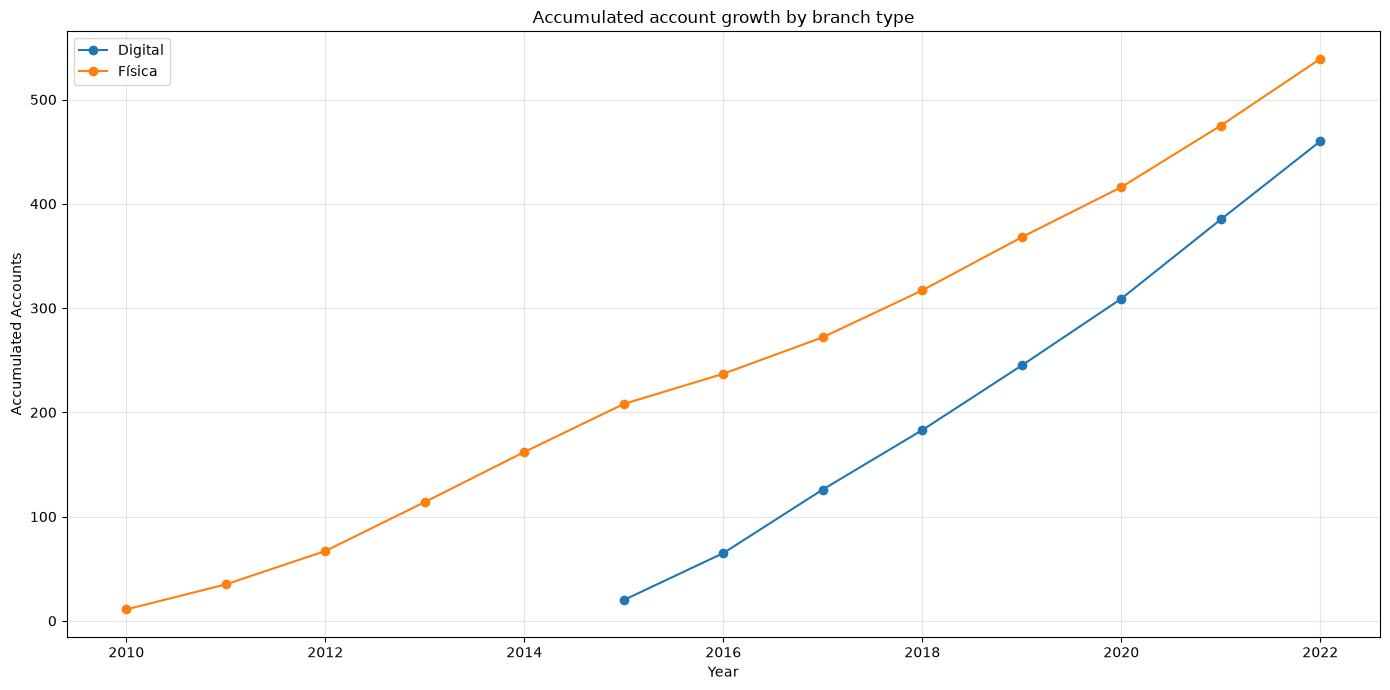

In [32]:
#Analise da tendência do crescimento acumulado de contas ao longo dos anos, segmentado por tipo de agência.
plt.figure(figsize=(14, 7))

for agency_type in account_growth_df["tipo_agencia"].unique():

    agency_data: pd.DataFrame = (
        account_growth_df[
            account_growth_df["tipo_agencia"] == agency_type
        ]
        .sort_values("opening_year")
    )

    plt.plot(
        agency_data["opening_year"],
        agency_data["cumulative_accounts"],
        marker="o",
        label=agency_type
    )

plt.xlabel("Year")
plt.ylabel("Accumulated Accounts")
plt.title("Accumulated account growth by branch type")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
#Observações:
    #Desde a introdução das agências digitais em 2015, o número de contas associadas a esse canal cresceu de forma consistente, 
    #atingindo um total acumulado de 460 contas em 2022. Embora as agências físicas ainda detivessem uma base acumulada maior (539 contas), 
    #a diferença diminuiu de 188 contas em 2015 para 79 em 2022, indicando uma adoção progressiva do canal bancário digital.

### Accounts & Customers analyses

#### Quarantine - Account without customer 

In [34]:
#Será analisado o dataset contas.csv nessa seção e sua relação com os demais datasets:
    #Quantos clientes possuem pelo menos uma conta
    #Quantos clientes possuem mais de uma conta
    #Identificar conta sem cliente correspondente vista na etapa de data quality

#Função para analisar a relação entre clientes e contas bancárias e identificar principalmente contas não correspondentes a clientes
customer_account_analysis: dict[str, int | float | pd.DataFrame] = analytic.analyze_customer_accounts(
        new_datasets["clientes"],
        new_datasets["contas"]
    )

print(
    f"Total customers: "
    f"{customer_account_analysis['total_customers']}"
)

print(
    f"Total accounts: "
    f"{customer_account_analysis['total_accounts']}"
)

print(
    f"Customers with at least one account: "
    f"{customer_account_analysis['customers_with_accounts']}"
)

print(
    f"Customers with multiple accounts: "
    f"{customer_account_analysis['customers_with_multiple_accounts']}"
)

print(
    f"Accounts without corresponding customer: "
    f"{customer_account_analysis['accounts_without_customer']}"
)

print(f"{'=' * 50}")

#Evidenciando a conta cujo cliente não foi encontrado
print(
    f"Accounts without corresponding customer: \n"
    f"{new_datasets["contas"].loc[
        customer_account_analysis["unmatched_account_indices"],
        ["num_conta", "cod_cliente"]
    ]}"
)

Total customers: 998
Total accounts: 999
Customers with at least one account: 998
Customers with multiple accounts: 0
Accounts without corresponding customer: 1
Accounts without corresponding customer: 
    num_conta  cod_cliente
24        528          528


In [35]:
#Observações:
    #A conta 528 referencia o cliente 528, porém esse identificador não está presente no cadastro de clientes, logo não há como saber que cliente é esse
    #O registro representa uma quebra de integridade referencial entre contas e clientes, porém não será apagado ainda, pois será analisado se essa conta possui histórico de transações

In [36]:
#Identificando os dados da conta 528
account: pd.DataFrame = new_datasets["contas"][
    new_datasets["contas"]["num_conta"] == 528
]

print("=== ACCOUNT ===")
print(account.to_string(index=False))


#Extraindo os FKs da conta 528 para análise de relacionamento com cliente, agência, colaboradores e transações
account_number: int = int(account["num_conta"].iloc[0])
customer_code: int = int(account["cod_cliente"].iloc[0])
agency_code: int = int(account["cod_agencia"].iloc[0])
employee_code: int = int(account["cod_colaborador"].iloc[0])


#Relação com cliente
customer: pd.DataFrame = new_datasets["clientes"][
    new_datasets["clientes"]["cod_cliente"] == customer_code
]

print(f"{'=' * 50}")
print("\n=== CUSTOMER RELATIONSHIP ===")
if customer.empty:
    print(f"No customer found for cod_cliente = {customer_code}")
else:
    print(customer.to_string(index=False))


#Relação com agência
agency: pd.DataFrame = new_datasets["agencias"][
    new_datasets["agencias"]["cod_agencia"] == agency_code
]

print(f"{'=' * 50}")
print("\n=== AGENCY RELATIONSHIP ===")
print(agency.to_string(index=False))


#Relação com colaboradores
employee: pd.DataFrame = new_datasets["colaboradores"][
    new_datasets["colaboradores"]["cod_colaborador"] == employee_code
]

print(f"{'=' * 50}")
print("\n=== EMPLOYEE RELATIONSHIP ===")
print(employee.to_string(index=False))


#Relação com transações
transactions: pd.DataFrame = new_datasets["transacoes"][
    new_datasets["transacoes"]["num_conta"] == account_number
]

print(f"{'=' * 50}")
print("\n=== TRANSACTION RELATIONSHIP ===")
print(
    f"Number of transactions: {len(transactions)}"
)

print(
    transactions.to_string(index=False)
)

=== ACCOUNT ===
 num_conta  cod_cliente  cod_agencia  cod_colaborador tipo_conta             data_abertura  saldo_total  saldo_disponivel    data_ultimo_lancamento
       528          528            1               23         PF 2013-08-15 14:41:00+00:00    7243.5916           7380.67 2018-09-04 03:56:17+00:00

=== CUSTOMER RELATIONSHIP ===
No customer found for cod_cliente = 528

=== AGENCY RELATIONSHIP ===
 cod_agencia           nome                                                        endereco    cidade uf             data_abertura tipo_agencia
           1 Agência Matriz Av. Paulista, 1436 - Cerqueira César, São Paulo - SP, 01310-916 São Paulo SP 2010-01-01 00:00:00+00:00       Física

=== EMPLOYEE RELATIONSHIP ===
 cod_colaborador primeiro_nome ultimo_nome              email            cpf           data_nascimento                                                      endereco      cep
              23         Elisa      Fogaça qjesus@example.net 579.816.234-64 1988-08-16 00:00:0

In [37]:
#Observações:
    #A conta 528 posui um histórico ativo nos datasets, incluindo várias transações

#Recomendação: 
    #Possivelmente houve perda de dados do cliente o que representa quebra de integridade, 
    #mas por regra não poddemos deletar essa contam ela deve ser tratada como anomalia e movida para quarentena (a avaliar como criar essa quarentena)

#### Insight - New customers per year

In [38]:
#Será analisado:
    #Adesão de novos clientes por ano na BanVic

#Função que calcula a quantidade de novos clientes por ano e % de de crescimento anual
new_customers_by_year = analytic.analyze_new_customers_by_year(
    new_datasets["contas"]
)

display(new_customers_by_year)

,year,new_customers,growth_percentage
0,2010,11,NaN
1,2011,24,118.181818
2,2012,32,33.333333
3,2013,47,46.875000
4,2014,48,2.127660
5,2015,66,37.500000
6,2016,74,12.121212
7,2017,96,29.729730
8,2018,102,6.250000
9,2019,113,10.784314


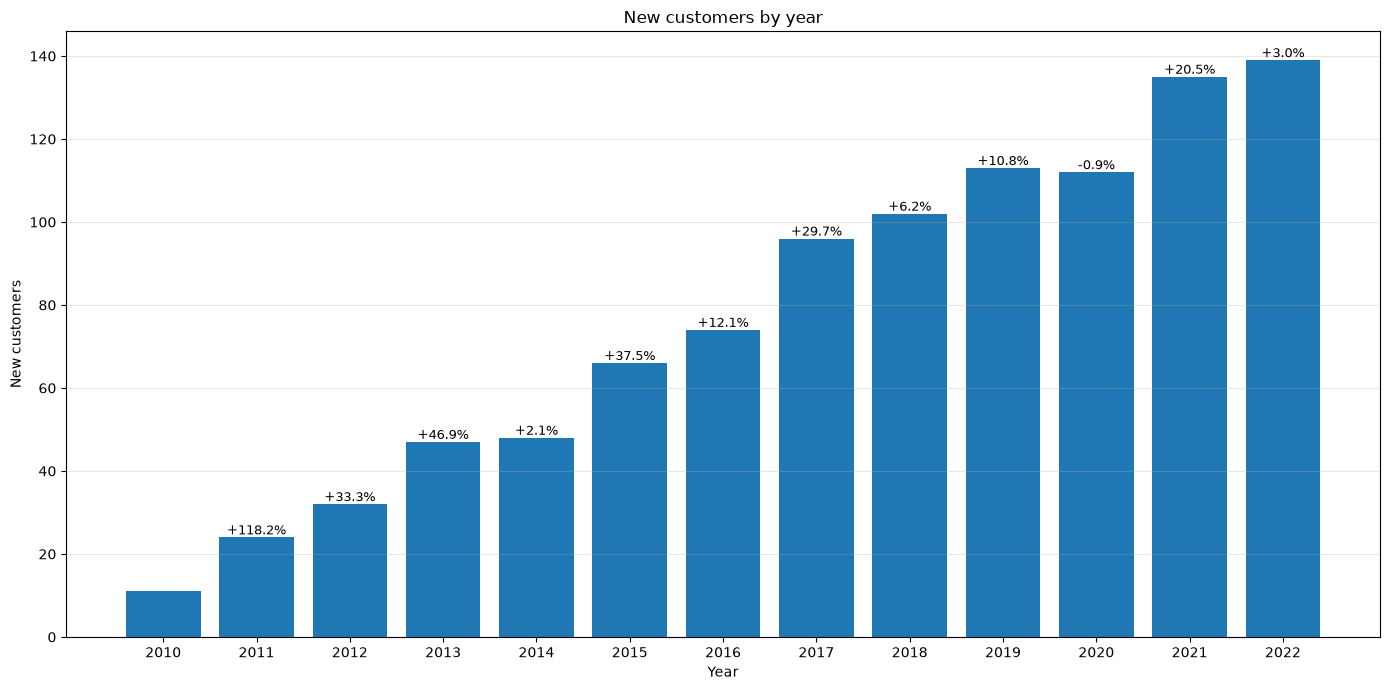

In [39]:
#Analise grafica da quantidade de novos clientes por ano, exibindo o crescimento percentual como rótulo de dados.
plt.figure(figsize=(14, 7))

bars = plt.bar(
    new_customers_by_year["year"],
    new_customers_by_year["new_customers"]
)

plt.xlabel("Year")
plt.ylabel("New customers")
plt.title("New customers by year")
plt.xticks(new_customers_by_year["year"])
plt.grid(axis="y", alpha=0.3)

for bar, growth in zip(
    bars,
    new_customers_by_year["growth_percentage"]
):
    if pd.notna(growth):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{growth:+.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

In [40]:
#Observações:
    #Nota-se um crescimento constante positivo de clientes todos os anos na Banvic, com exceção do ano de 2020, 
    #porém a queda no número de clientes nesse ano em relação a 2019 não chega nem a 1% (diferença de 1 cliente) 
    #e possivelmente esta associado ao fator histórico do ano em questão: a pandemia do Covid-19

    #Importante ressaltar que de 2010 para 2011 a quantidade de clientes mais do que dobrou representando a maior % de crescimento dessa analise anual, 
    #mas a quantidade absoluta de clientes era pequena (menos de 25 clientes) e isso causou essa inflação

#Recomendação:
    #Analisar a relação de atividade e inatividade desses clientes

#### Insight - Active vs. Inactive customers + Churn rate

In [41]:
#Será analisado:
    #Quantidade de clientes ativos hoje na BanVic
    #Probabilidade do risco de churn em KPI (churn rate)

#Primeiramente, vamos definir um periodo anual para tomar de referência para definir a atividade e inatividade dos clientes
annual_transactions: pd.DataFrame = (
    new_datasets["transacoes"]
    .assign(
        transaction_year=lambda df: (
            df["data_transacao"]
            .dt.tz_localize(None)
            .dt.year
        )
    )
    .groupby("transaction_year")
    .agg(
        transaction_count=("cod_transacao", "count")
    )
    .reset_index()
)

display(annual_transactions)

,transaction_year,transaction_count
0,2010,93
1,2011,367
2,2012,734
3,2013,1249
4,2014,1503
5,2015,1897
6,2016,2604
7,2017,3554
8,2018,3945
9,2019,5428


In [42]:
#Observação:
    #Será considerado o ano de 2022 como referência para definição das atividades dos clientes, por apresentar a maior quantidade de atividades
    #Aparentemente o ano de 2023 está incompleto, o que nos leva a crer que a base foi extraída nesse ano, logo toma-se como premissa o ano 2022 por ser mais completo

#Recomentação
    #Analisar futuramente a evolução das transações com mais detalhes, especialmente o ano de 2022

In [43]:
#Função que classifica clientes ativos (pelo menos 1 transação) vs. clientes inativos (sem transações) em 2022
customer_activity_2022 = analytic.analyze_customer_activity_2022(
    new_datasets["clientes"],
    new_datasets["transacoes"],
    new_datasets["contas"]
)

display(customer_activity_2022)

,activity_status,customer_count,percentage
0,Active,782,78.36
1,No transactions,216,21.64


In [44]:
#Observação:
    #Atenção! Aproximadamente 1 em cada 5 clientes da base não apresentou atividade transacional em 2022

    #Porém, ainda não devemos chamar os 21,64% de clientes churned ou afirmar que essa é a probabilidade de churn
    #Eles são clientes sem transações em 2022. Para falar em churn, precisamos definir uma janela temporal de inatividade

#Recomendação:
    #Fazer levantamento ano a ano agora para ver se essa tendência se repetiu em cada ano
    #Calcular a taxa de churn ano a ano, sendo que será adota -> churn rate (%) = (inativos do ano atual / ativos do ano anterior) * 100


In [45]:
#Função que classifica clientes ativos (pelo menos 1 transação) vs. clientes inativos (sem transações) + churn rate em todos os anos
customer_activity_by_year = analytic.analyze_customer_activity_by_year(
    new_datasets["clientes"],
    new_datasets["transacoes"],
    new_datasets["contas"]
)

#[0] retorna -> dataframe atividade x inatividade ano a ano
display(customer_activity_by_year[0])
customer_activity_by_year_df = customer_activity_by_year[0]

,transaction_year,activity_status,customer_count,percentage
0,2010,Active,11,100.000000
1,2011,Active,31,88.571429
2,2011,No transactions,4,11.428571
3,2012,Active,50,74.626866
4,2012,No transactions,17,25.373134
5,2013,Active,97,85.840708
6,2013,No transactions,16,14.159292
7,2014,Active,112,69.565217
8,2014,No transactions,49,30.434783
9,2015,Active,150,66.079295


In [46]:
#[1] retorna -> dataframe churn rate ano a ano
display(customer_activity_by_year[1])
churn_rate_by_year_df = customer_activity_by_year[1]

,transaction_year,previous_active_customers,churned_customers,churn_rate
0,2010,0,0,None
1,2011,11,4,36.363636
2,2012,31,13,41.935484
3,2013,50,12,24.0
4,2014,97,38,39.175258
5,2015,112,40,35.714286
6,2016,150,47,31.333333
7,2017,201,72,35.820896
8,2018,253,95,37.549407
9,2019,300,102,34.0


In [47]:
#Observações:
    #Para ambos os casos, incluindo o churn rate foi adotado o periodo anual como referência
    #Percebe-se que em ambos os dataframes o ano de 2023 está incompleto, portanto será desconsiderado da base
    #Para o churn rate, será desconsiderado o ano de 2010 também, pois não temos o ano anterior para calcular a taxa

churn_rate_by_year_df = churn_rate_by_year_df[churn_rate_by_year_df["transaction_year"].between(2010, 2022)]
customer_activity_by_year_df = customer_activity_by_year_df[customer_activity_by_year_df["transaction_year"].lt(2023)]

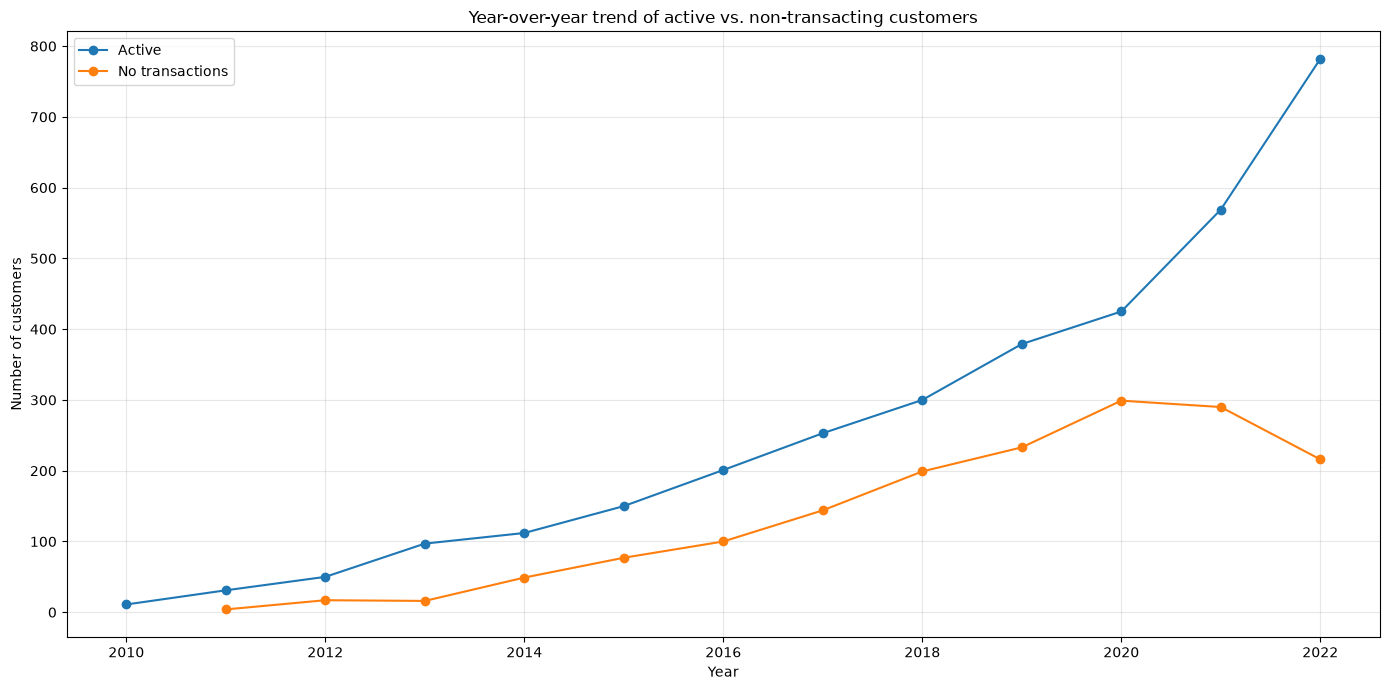

In [48]:
#Analise grafica clientes ativos (pelo menos 1 transação) vs. clientes inativos (sem transações) em todos os anos (considera a data de abertura da conta) (desconsiderando o ano de 2023)
plt.figure(figsize=(14, 7))

for status in ["Active", "No transactions"]:
    status_data = customer_activity_by_year_df[
        customer_activity_by_year_df["activity_status"] == status
        
    ].sort_values("transaction_year")

    plt.plot(
        status_data["transaction_year"],
        status_data["customer_count"],
        marker="o",
        label=status
    )

plt.xlabel("Year")
plt.ylabel("Number of customers")
plt.title("Year-over-year trend of active vs. non-transacting customers")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [49]:
#Observações:
    #2020 -> 2022 é onde aparece uma mudança relevante no comportamento da base
    #O numero de clientes ativos e inativos apresentou tendências similares até 2020, com o número de clientes ativos sempre sendo maior, 
    #sendo que a partir de 2021 houve um aumento significativo de 66.23% que explica uma adesão crescente de novos clientes anualmente

#recomendação:
    #Analisar tendência do percentual de clientes ativos 

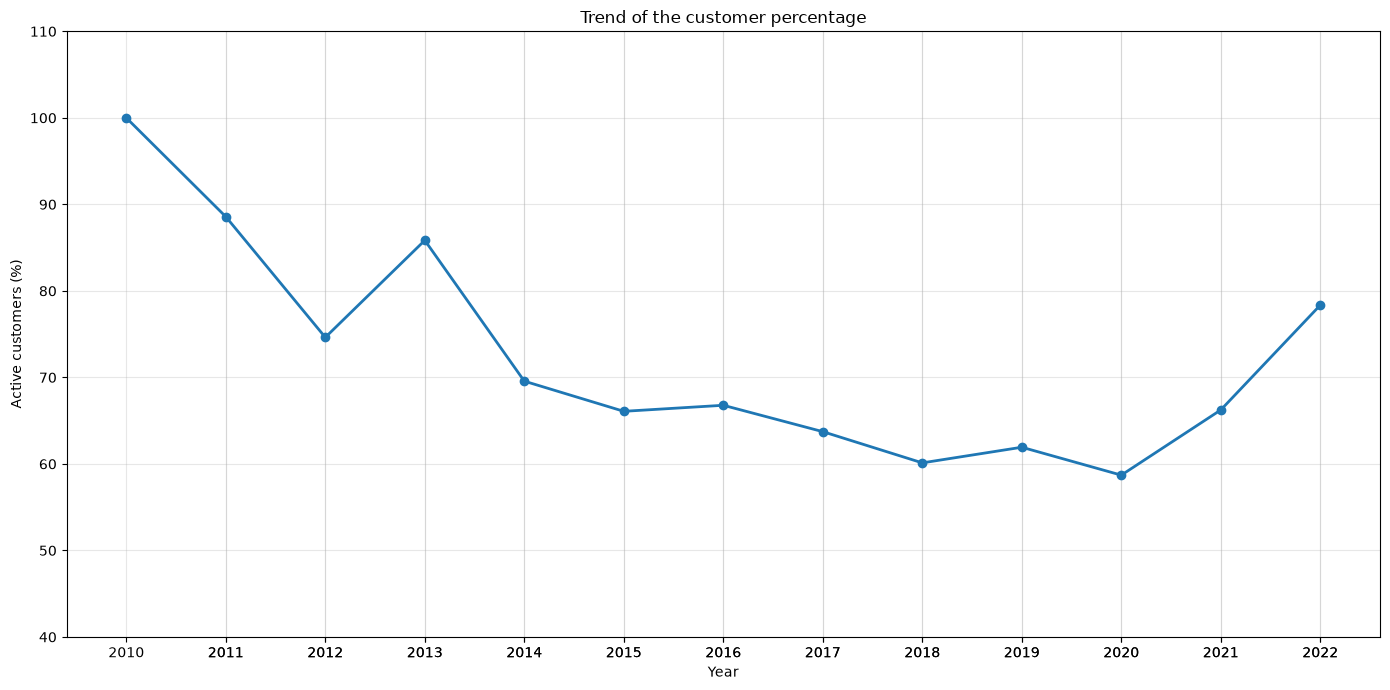

In [50]:
#Análise grafica da tendência do percentual de clientes ativos (desconsiderando o ano de 2023)
plt.figure(figsize=(14, 7))


active_data = (
    customer_activity_by_year_df[
        customer_activity_by_year_df["activity_status"].eq("Active")
    ]
    .sort_values("transaction_year")
)

plt.plot(
    active_data["transaction_year"],
    active_data["percentage"],
    marker="o",
    linewidth=2
)

plt.xlabel("Year")
plt.ylabel("Active customers (%)")
plt.title("Trend of the customer percentage")
plt.ylim(40, 110)
plt.xticks(customer_activity_by_year_df["transaction_year"])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [51]:
#Observações:
    #A proporção de clientes ativos apresentou tendência de queda entre 2013 e 2020, atingindo 58,7% em 2020
    #A partir de 2021, observa-se uma recuperação da atividade, chegando a 66,2% em 2021 e 78,4% em 2022
    #O resultado indica uma mudança relevante no nível de engajamento transacional da base nos últimos anos completos analisados

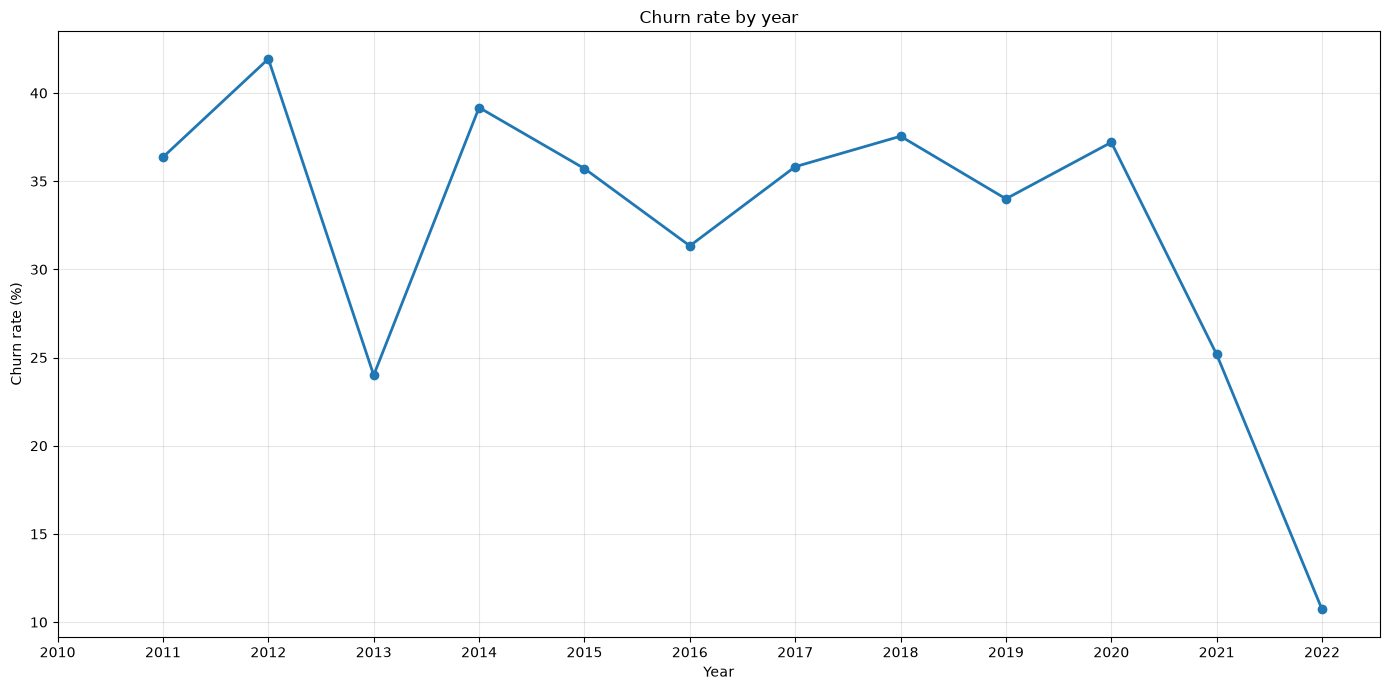

In [52]:
#Análise grafica da percentual do churn rate anual (desconsiderando o ano de 2023 e 2010)
plt.figure(figsize=(14, 7))


active_data = (
    churn_rate_by_year_df
        
    .sort_values("transaction_year")
)

plt.plot(
    active_data["transaction_year"],
    active_data["churn_rate"],
    marker="o",
    linewidth=2
)

plt.xlabel("Year")
plt.ylabel("Churn rate (%)")
plt.title("Churn rate by year")
plt.xticks(churn_rate_by_year_df["transaction_year"])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [53]:
#Observações:
    #O comportamento do churn muda significativamente a partir de 2021 -> Entre 2011 e 2020, o churn permaneceu relativamente elevado, variando entre 24,0% e 41,9%
    #O maior valor de churn ocorreu em 2012: 41,9%, enquanto 2020 apresentou 37,2%
    #Em 2021, o churn caiu para 25,2%, uma redução de aproximadamente 12 p.p. em relação a 2020
    #Em 2022, ocorreu uma queda ainda mais expressiva, para apenas 10,7% (cerca de 14,5 p.p. abaixo de 2021)
    #Portanto, entre 2020 e 2022, o churn caiu de 37,2% para 10,7%, enquanto a proporção de clientes ativos aumentou de 58,7% para 78,4%

#Recomendação:
    #Investigar os fatores associados à redução acentuada do churn a partir de 2021, particularmente em 2022 nas transações e propostas de créditos

### Transactions analyses

#### Insight - Transactions types - Overview

In [54]:
#Será analisado:
    #Quais tipos de transação concentram o maior volume de operações no BanVic

#Função que analisa quantidade de transações por tipo
transaction_volume: pd.DataFrame = (
    analytic.analyze_transaction_volume_by_type(
        new_datasets["transacoes"]
    )
)

display(transaction_volume)

,nome_transacao,transaction_count
0,Compra Crédito,24977
1,Compra Débito,17662
7,Pix - Realizado,13164
8,Pix - Recebido,5134
4,Depósito em espécie,4866
10,Saque,2879
12,TED - Recebido,1005
6,Pagamento de boleto,452
13,Transferência entre CC - Crédito,441
5,Estorno de Debito,403


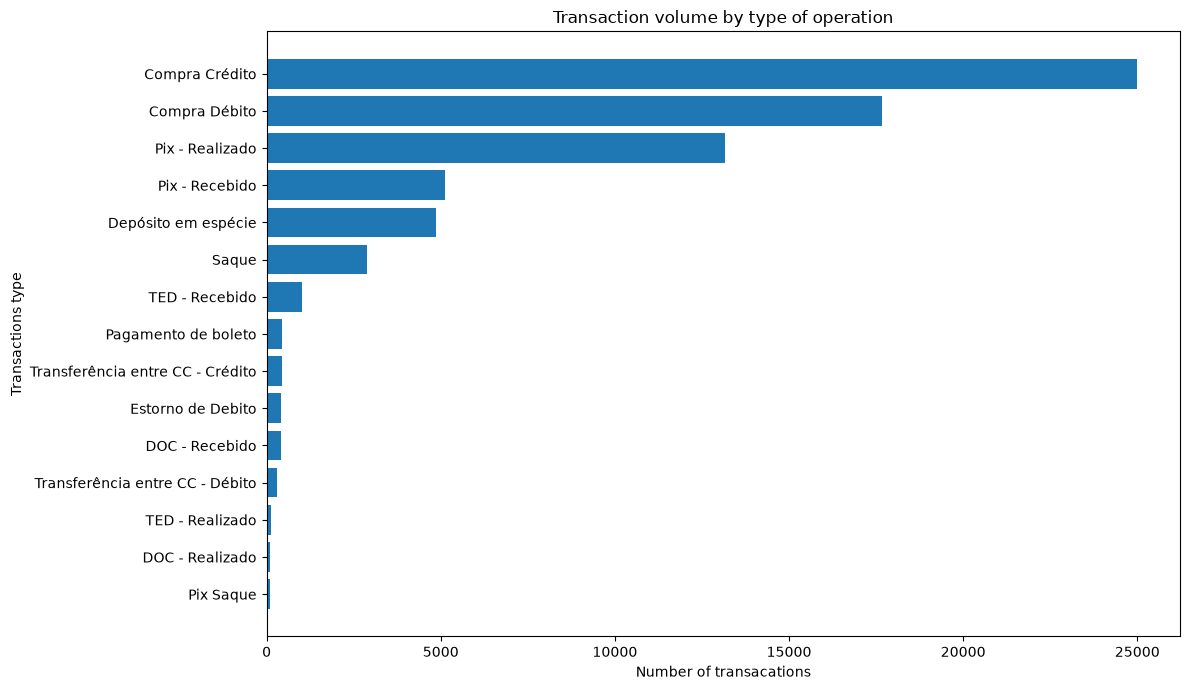

In [55]:
#Analise grafica da quantidade de transações por tipo ao longo do periodo total
plt.figure(figsize=(12, 7))

transaction_data: pd.DataFrame = (
    transaction_volume
    .sort_values("transaction_count")
)

plt.barh(
    transaction_data["nome_transacao"],
    transaction_data["transaction_count"]
)

plt.xlabel("Number of transacations")
plt.ylabel("Transactions type")
plt.title("Transaction volume by type of operation")

plt.tight_layout()
plt.show()

In [56]:
#Observações:
    #O volume de transações concentra-se em compras no crédito (24977) e no débito (17662) que, juntas, representam quase 60% de todas as transações
    #O PIX também representa uma parcela significativa da atividade do banco
    #Ao combinar as transações de PIX saque, realizadas e recebidas, esse meio de pagamento corresponde a 25,5% do volume total de transações (18388), sendo o segundo maior no geral

#Recomendação:
    #Explorar os efeitos da adoção do PIX nas transações por ser uma tecnologia nova e emergente no mercado

#### Insight - Transactions evolution - Overview

In [57]:
#Será analisado o dataset transacoes nessa seção e sua relação com os demais datasets:
    #Evolução mensal das transações por tipo de agência
    #Relação do clientes com tipo de agência

#Função para analisar a evolução das transações bancárias ao longo do periodo mensal
monthly_transactions: pd.DataFrame = analytic.analyze_transaction_evolution(
    new_datasets["transacoes"]
)
print(monthly_transactions.describe())

#Será gerado um dataset em CSV para registrar essa analise (opcional)
monthly_transactions.to_csv("../data/transacao_analytics.csv")

       transaction_count  total_transaction_value  average_transaction_value
count         156.000000             1.560000e+02                 155.000000
mean          461.532051             1.647786e+05                 577.825787
std          2023.756314             4.073763e+05                 769.779384
min             0.000000            -8.145585e+04               -1313.804032
25%            89.500000             1.853278e+04                 117.182912
50%           218.500000             9.486621e+04                 389.759091
75%           453.750000             1.839465e+05                 735.245406
max         25319.000000             4.792583e+06                4741.914286


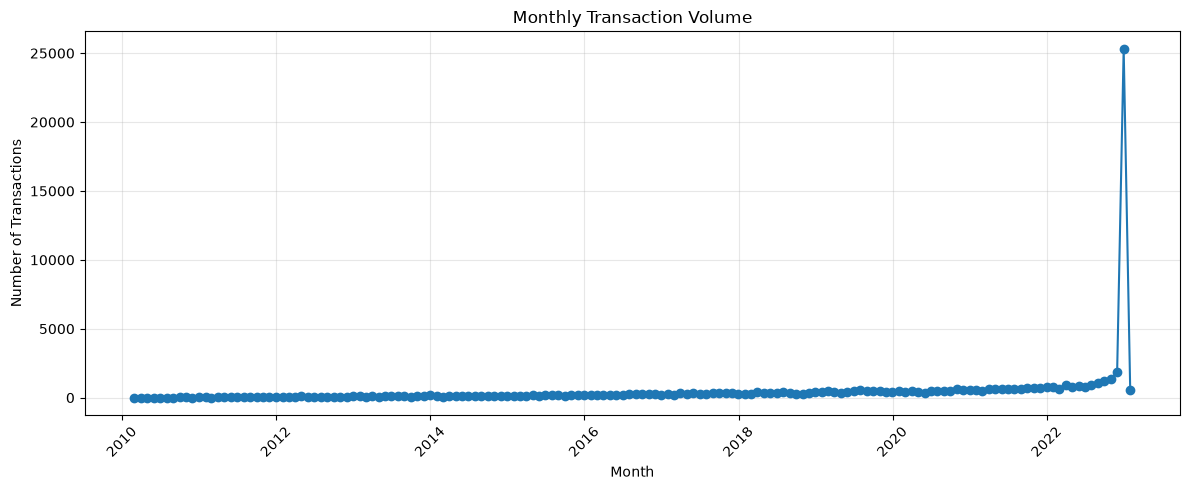

In [58]:
#Analise da tendência das transações ao longo do periodo mensal (quantidade de transações por mês)
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_transactions["data_transacao"],
    monthly_transactions["transaction_count"],
    marker="o"
)

plt.title("Monthly Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [59]:
#Observações:
    #Em 12-2022 houve um aumento não homogeneo das transações, para tanto será necessário investigar melhor essa tendência
    #Nota-se que foram 25319 transações em 12-2022 contra 1841 em 11-2022 -> ~1275% de aumento aproximadamente

#Recomendação: 
    #Será necessário entender esse pico anômalo de 2022

In [60]:
#Analise das 10 maiores transações diárias
daily_transactions: pd.DataFrame = (
    new_datasets["transacoes"]
    .set_index("data_transacao")
    .resample("D")
    .agg(
        transaction_count=("cod_transacao", "count"),
        total_transaction_value=("valor_transacao", "sum")
    )
    .reset_index()
)

daily_transactions.sort_values(
    "transaction_count",
    ascending=False
).head(10)

,data_transacao,transaction_count,total_transaction_value
4688,2022-12-29 00:00:00+00:00,13825,2789538.75
4689,2022-12-30 00:00:00+00:00,6612,1028842.34
4687,2022-12-28 00:00:00+00:00,690,88925.03
4686,2022-12-27 00:00:00+00:00,474,256967.87
4685,2022-12-26 00:00:00+00:00,313,261488.79
4684,2022-12-25 00:00:00+00:00,289,96972.19
4683,2022-12-24 00:00:00+00:00,277,9209.08
4682,2022-12-23 00:00:00+00:00,204,-14323.19
4680,2022-12-21 00:00:00+00:00,200,23825.41
4681,2022-12-22 00:00:00+00:00,199,28246.41


In [61]:
#Observações:
    #Basicamente as 10 maiores quantidade de transações diárias ocorrem nos ultimos dias de 12-2022

#Recomendação: 
    #Será necessário complementar com o valor das transações para entender se a tendência se repete

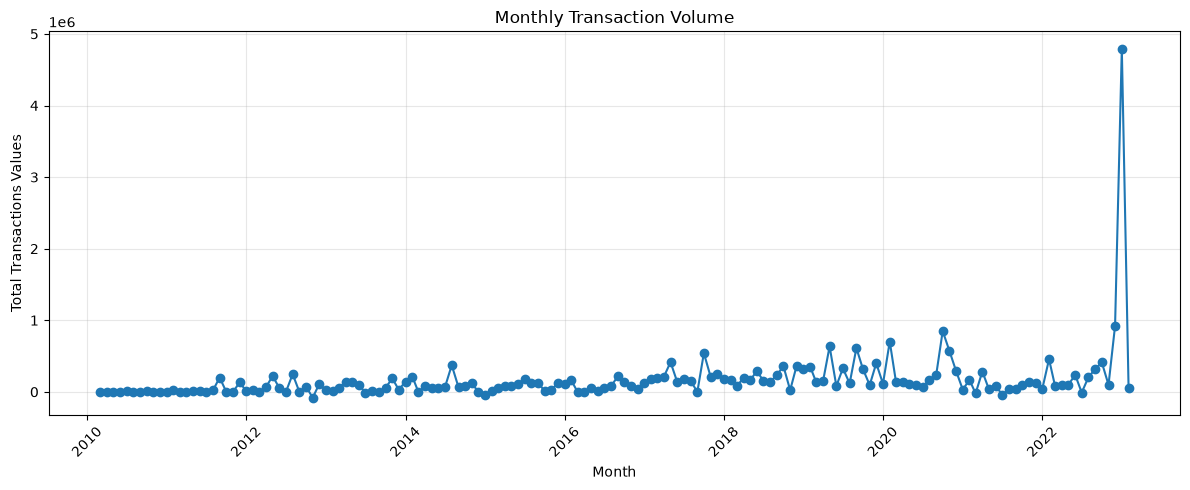

In [62]:
#Analise da tendência das transações ao longo do periodo mensal (valor de transações por mês)
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_transactions["data_transacao"],
    monthly_transactions["total_transaction_value"],
    marker="o"
)

plt.title("Monthly Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Total Transactions Values")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [63]:
#Observações:
    #Aproximadamente 80% de todas as 25319 transações de 12-2022 ocorreram em apenas dois dias (29 e 30)
    #A concentração também se reflete no valor financeiro transacionado, caracterizando um comportamento atípico no período

#Recomendação: 
    #Investigar quais tipos de transação e quais clientes/contas foram responsáveis pelo pico de 12-2022
    #Será tomado como base os dias 29 e 30 de 12-2022, por serem significativamente quase toda a amostra

In [64]:
#Analise dos dias 29 e 30 de dezembro por tipo de transações realizadas
peak_transactions: pd.DataFrame = (
    new_datasets["transacoes"]
    .loc[
        new_datasets["transacoes"]["data_transacao"].dt.date.isin(
            [
                pd.Timestamp("2022-12-29").date(),
                pd.Timestamp("2022-12-30").date()
            ]
        )
    ]
    .assign(
        transaction_date=lambda df: df["data_transacao"].dt.date
    )
    .groupby(
        ["transaction_date", "nome_transacao"]
    )
    .agg(
        transaction_count=("cod_transacao", "count"),
        total_transaction_value=("valor_transacao", "sum")
    )
    .sort_values(
        ["transaction_date", "transaction_count"],
        ascending=[True, False]
    )
    .reset_index()
)

display(peak_transactions)

,transaction_date,nome_transacao,transaction_count,total_transaction_value
0,2022-12-29,Compra Crédito,4053,-221967.77
1,2022-12-29,Pix - Realizado,4018,-2087094.00
2,2022-12-29,Compra Débito,2751,-149609.70
3,2022-12-29,Pix - Recebido,1543,913927.90
4,2022-12-29,Depósito em espécie,514,32402.91
5,2022-12-29,Saque,497,-139220.00
6,2022-12-29,TED - Recebido,100,3233050.00
7,2022-12-29,Pagamento de boleto,78,-85972.00
8,2022-12-29,Transferência entre CC - Crédito,59,36072.60
9,2022-12-29,DOC - Recebido,54,2027660.00


In [65]:
#Observações:
    #O pico de 29 e 30 de 12-2022 foi concentrado principalmente em PIX, compras no crédito e débito, com forte predominância de operações em 29/12/22
    #Em valor financeiro, TED e DOC recebidos apresentaram impacto desproporcional ao volume de operações.

#Recomendação:  
    #Investigar a concentração dessas operações por cliente e conta 
    #Identificar quais participantes foram responsáveis pelo comportamento atípico

In [66]:
#Analise das 10 maiores transações diárias por tipo de conta de cliente nos dias 29 e 30 de 12-2022 (quantidade de transações)
peak_accounts: pd.DataFrame = (
    new_datasets["transacoes"]
    .loc[
        new_datasets["transacoes"]["data_transacao"].dt.date.isin(
            [
                pd.Timestamp("2022-12-29").date(),
                pd.Timestamp("2022-12-30").date()
            ]
        )
    ]
    .groupby("num_conta")
    .agg(
        transaction_count=("cod_transacao", "count"),
        total_transaction_value=("valor_transacao", "sum")
    )
    .sort_values("transaction_count", ascending=False)
    .reset_index()
)

peak_accounts.head(10)

,num_conta,transaction_count,total_transaction_value
0,754,87,-269.58
1,180,86,2755.09
2,687,86,42641.15
3,9,75,75739.07
4,686,75,9409.67
5,422,75,-83.34
6,844,74,16469.86
7,670,74,40315.50
8,538,74,2401.90
9,939,73,-6296.06


In [67]:
#Observações:
    #O aumento de volume em 29 e 30 de 12-2022 parece ter sido distribuído entre várias contas, e não provocado por uma única conta dominante

#Recomendação:  
    #Investigar o valor acumulativo e aumentar a amostra para 20

In [68]:
#Analise cumulativa das 20 primeiras contas bancarias ordenadas pelo total do valor investido e o acumulativo da quantidade de transações
peak_accounts = peak_accounts.sort_values(
    "total_transaction_value",
    ascending=False
).reset_index(drop=True)

peak_accounts["cumulative_transaction_count"] = (
    peak_accounts["transaction_count"].cumsum()
)

total_peak_transactions: int = peak_accounts["transaction_count"].sum()

peak_accounts["cumulative_share"] = (
    peak_accounts["cumulative_transaction_count"]
    / total_peak_transactions
)

peak_accounts.head(20)

,num_conta,transaction_count,total_transaction_value,cumulative_transaction_count,cumulative_share
0,18,49,203726.68,49,0.002398
1,338,29,178566.68,78,0.003817
2,197,35,163506.82,113,0.005529
3,484,19,148649.15,132,0.006459
4,426,58,139682.20,190,0.009297
5,411,54,139588.09,244,0.011939
6,56,54,138884.71,298,0.014581
7,499,60,130015.80,358,0.017517
8,597,32,108289.73,390,0.019083
9,101,8,104704.78,398,0.019474


In [69]:
#Observações:
    #Valor financeiro e quantidade de transações não estão diretamente relacionados nesses dois dias
    #A conta 484, por exemplo, movimentou R$ 148,6 mil com apenas 19 operações, enquanto a conta 426 fez 58 operações e movimentou R$ 139,7 mil.

In [70]:
#Analise cumulativa das 20 primeiras contas bancarias ordenadas pelo total do valor investido e o acumulativo do valor das transações
peak_accounts["cumulative_transaction_value"] = (
    peak_accounts["total_transaction_value"].cumsum()
)

total_peak_value: float = (
    peak_accounts["total_transaction_value"].sum()
)

peak_accounts["cumulative_value_share"] = (
    peak_accounts["cumulative_transaction_value"]
    / total_peak_value
)

peak_accounts.head(20)

,num_conta,transaction_count,total_transaction_value,cumulative_transaction_count,cumulative_share,cumulative_transaction_value,cumulative_value_share
0,18,49,203726.68,49,0.002398,203726.68,0.053354
1,338,29,178566.68,78,0.003817,382293.36,0.100119
2,197,35,163506.82,113,0.005529,545800.18,0.142940
3,484,19,148649.15,132,0.006459,694449.33,0.181870
4,426,58,139682.20,190,0.009297,834131.53,0.218452
5,411,54,139588.09,244,0.011939,973719.62,0.255008
6,56,54,138884.71,298,0.014581,1112604.33,0.291381
7,499,60,130015.80,358,0.017517,1242620.13,0.325431
8,597,32,108289.73,390,0.019083,1350909.86,0.353791
9,101,8,104704.78,398,0.019474,1455614.64,0.381213


In [71]:
#Observações:
    #R$ 2311516,78 são referentes a apenas 20 contas que representam o pico do grafico, equivalente a 60,54% de todo o valor transacionado no pico
    #Essas mesmas 20 contas representam apenas 737 transações, ou 3,61% do volume de operações
    #O pico em 29 e 30 de 12-2022 é amplamente distribuído em quantidade de operações, mas significativamente concentrado em valor financeiro
    #Esses dois dias representam um marco histórico nas operações de transações com uma grande concentração de valores monetários distribuidos em poucas contas

In [72]:
#Insights:
    #As 20 contas com maior valor transacionado nos dias 29 e 30 de 12-2022 concentraram 60,54% do valor financeiro, 
    #embora representassem apenas 3,61% das transações realizadas no período.
    #Esse resultado indica que o pico apresentou baixa concentração em volume de operações, mas alta concentração financeira, 
    #sugerindo a existência de contas com operações de maior valor que contribuíram de forma relevante para o movimento observado

    #No final isso pode exemplificar um marco histórico, como as eleições de 2022, que moveram altos investimentos bancários de débito e PIX
    #ou um movimento de geração de dados proposital que pode ser classificado como um achado técnico anômalo

#Recomendação:
    #Investigar essas contas sob a perspectiva de perfil dos clientes e tipos de transação, buscando identificar os fatores associados à concentração financeira

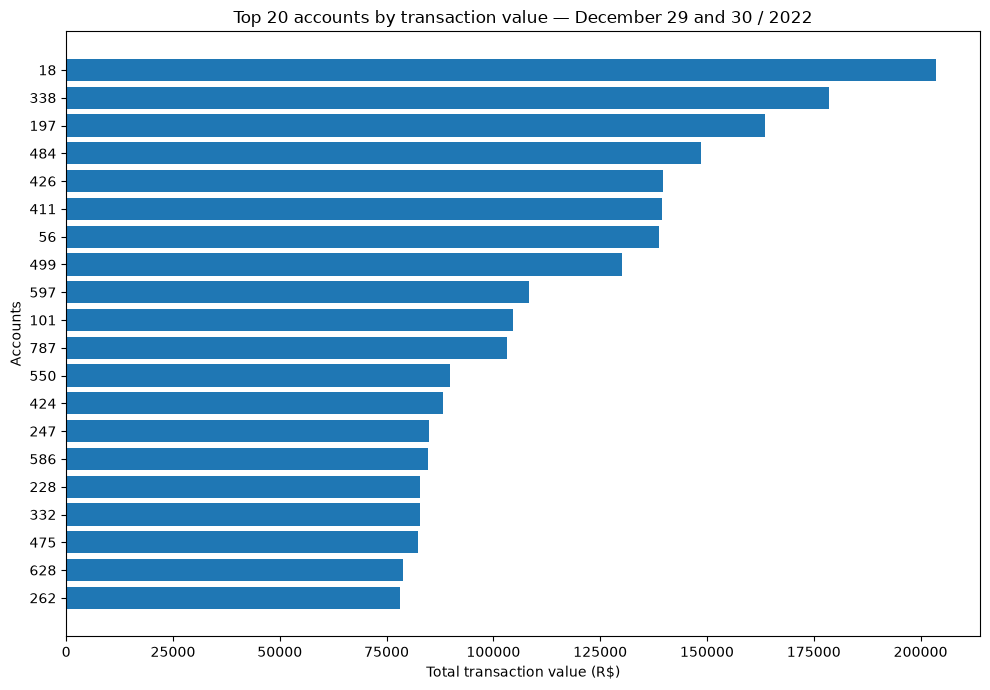

In [73]:
#Visualização gráfica das 20 maiores contas com valor financeiro transacionado durante o período de pico.
top_accounts: pd.DataFrame = (
    peak_accounts
    .nlargest(20, "total_transaction_value")
    .sort_values("total_transaction_value")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_accounts["num_conta"].astype(str),
    top_accounts["total_transaction_value"]
)

plt.xlabel("Total transaction value (R$)")
plt.ylabel("Accounts")
plt.title("Top 20 accounts by transaction value — December 29 and 30 / 2022")

plt.tight_layout()
plt.show()

In [74]:
#Será analisado agora:
    #Se o crescimento transacional observado em 2022 pode estar relacionado à mudança no comportamento de uso dos clientes 
    #E à adoção de novos meios de pagamento e plataformas digitais, especialmente o PIX
    #Quando foi adotado agências digitais e se isso impacta os dados

#Função para analise temporal entre clientes, contas, agências e transações
transaction_profile: pd.DataFrame = analytic.analyze_transaction_profile(
    new_datasets["transacoes"],
    new_datasets["contas"],
    new_datasets["clientes"],
    new_datasets["agencias"]
)

transaction_profile.head()

#Agrupando pela quantidade de transações -> Representa a quantidade de vezes que foi usada
transaction_profile.sort_values(
    "transaction_count",
    ascending=False
).reset_index(drop=True).head(10)

,transaction_month,tipo_cliente,tipo_agencia,nome_transacao,transaction_count,total_transaction_value
0,2022-12,PF,Digital,Compra Crédito,3883,-212266.44
1,2022-12,PF,Digital,Pix - Realizado,3865,-2018164.40
2,2022-12,PF,Física,Pix - Realizado,3539,-1834312.10
3,2022-12,PF,Física,Compra Crédito,3465,-190724.13
4,2022-12,PF,Digital,Compra Débito,2724,-156518.29
5,2022-12,PF,Física,Compra Débito,2401,-126464.43
6,2022-12,PF,Digital,Pix - Recebido,1503,900412.30
7,2022-12,PF,Física,Pix - Recebido,1307,769665.80
8,2022-12,PF,Digital,Depósito em espécie,510,33179.02
9,2022-12,PF,Digital,Saque,481,-127060.00


In [75]:
#Observações:
    #O pico de dezembro de 2022 foi predominantemente composto por transações de clientes PF (natural, pois só há clientes PF nos datasets)
    #O pico apresentou forte participação de operações associadas ao canal digital (agência digitais), especialmente PIX

#### Insight - Transactions evolution - Digital branch adoption

In [76]:
#Analise da evolução mensal do tipo de agência
channel_evolution: pd.DataFrame = analytic.prepare_channel_evolution(
    transaction_profile
)

channel_evolution.sort_values(
    "transaction_count",
    ascending=False
).reset_index(drop=True).head(10)

,transaction_month,tipo_agencia,transaction_count
0,2022-12,Digital,13394
1,2022-12,Física,11925
2,2022-11,Digital,949
3,2022-11,Física,892
4,2022-10,Digital,726
5,2022-10,Física,646
6,2022-09,Física,619
7,2022-09,Digital,611
8,2022-08,Digital,568
9,2022-03,Física,555


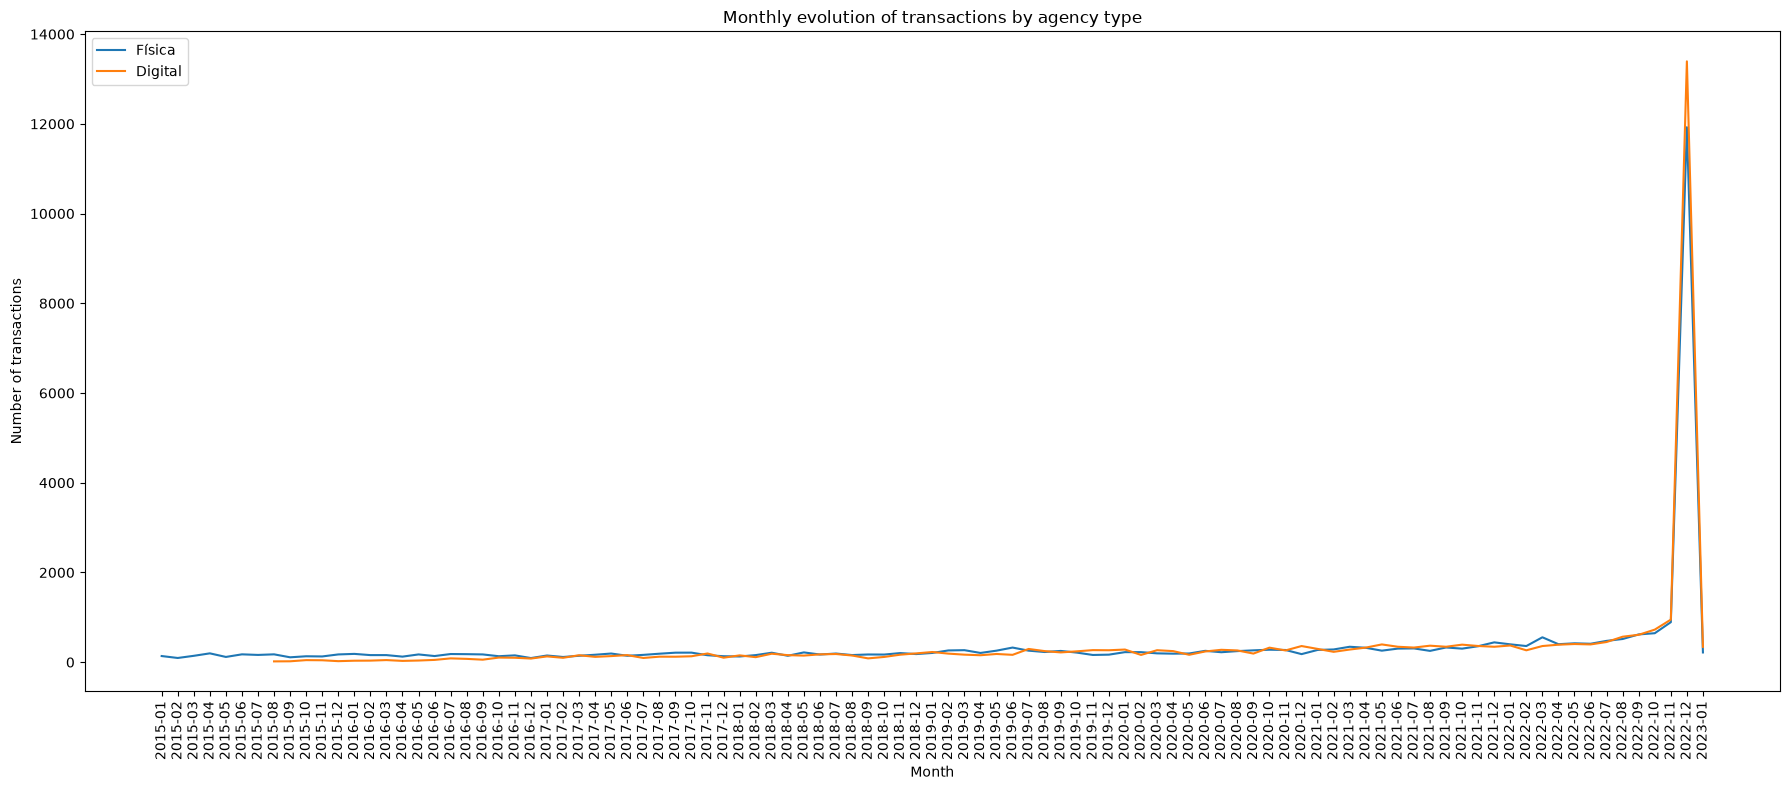

In [77]:
#Análise gráfica da evolução mensal das transações por tipo de agência
plt.figure(figsize=(18, 8))
for channel_type in channel_evolution["tipo_agencia"].unique():
    channel_data: pd.DataFrame = (
        channel_evolution[
            channel_evolution["tipo_agencia"] == channel_type
        ]
    )

    channel_data: pd.DataFrame = (
        channel_evolution[
            (channel_evolution["tipo_agencia"] == channel_type)
            & (channel_evolution["transaction_month"] >= "2015-01")
        ]
    )

    plt.plot(
        channel_data["transaction_month"].astype(str),
        channel_data["transaction_count"],
        label=channel_type
    )

plt.xlabel("Month")
plt.ylabel("Number of transactions")
plt.title("Monthly evolution of transactions by agency type")

plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [78]:
#Observação:
    #Dezembro de 2022 apresenta um pico excepcional de transações, superior à escala utilizada no gráfico 
    #A adoção das agências digitais ocorreu em 08-2015, sendo que o número de transações se manteve pareado com as físicas,
    #porém no pico de 12-2022 o número de transações das agências digitais ultrapassou em mais 2000 o número das físicas

#### Insight - Transactions evolution - PIX adoption

In [79]:
#Analise da evolução mensal por tipo de transação dando ênfase no PIX
pix_evolution: pd.DataFrame = analytic.prepare_pix_evolution(
    transaction_profile
)

pix_evolution.sort_values(
    "transaction_count",
    ascending=False
).reset_index(drop=True).head(10)

,transaction_month,transaction_group,transaction_count
0,2022-12,Others,15052
1,2022-12,PIX,10267
2,2022-11,Others,1092
3,2022-10,Others,820
4,2022-11,PIX,749
5,2022-09,Others,743
6,2022-08,Others,671
7,2020-10,Others,602
8,2022-03,Others,571
9,2019-07,Others,552


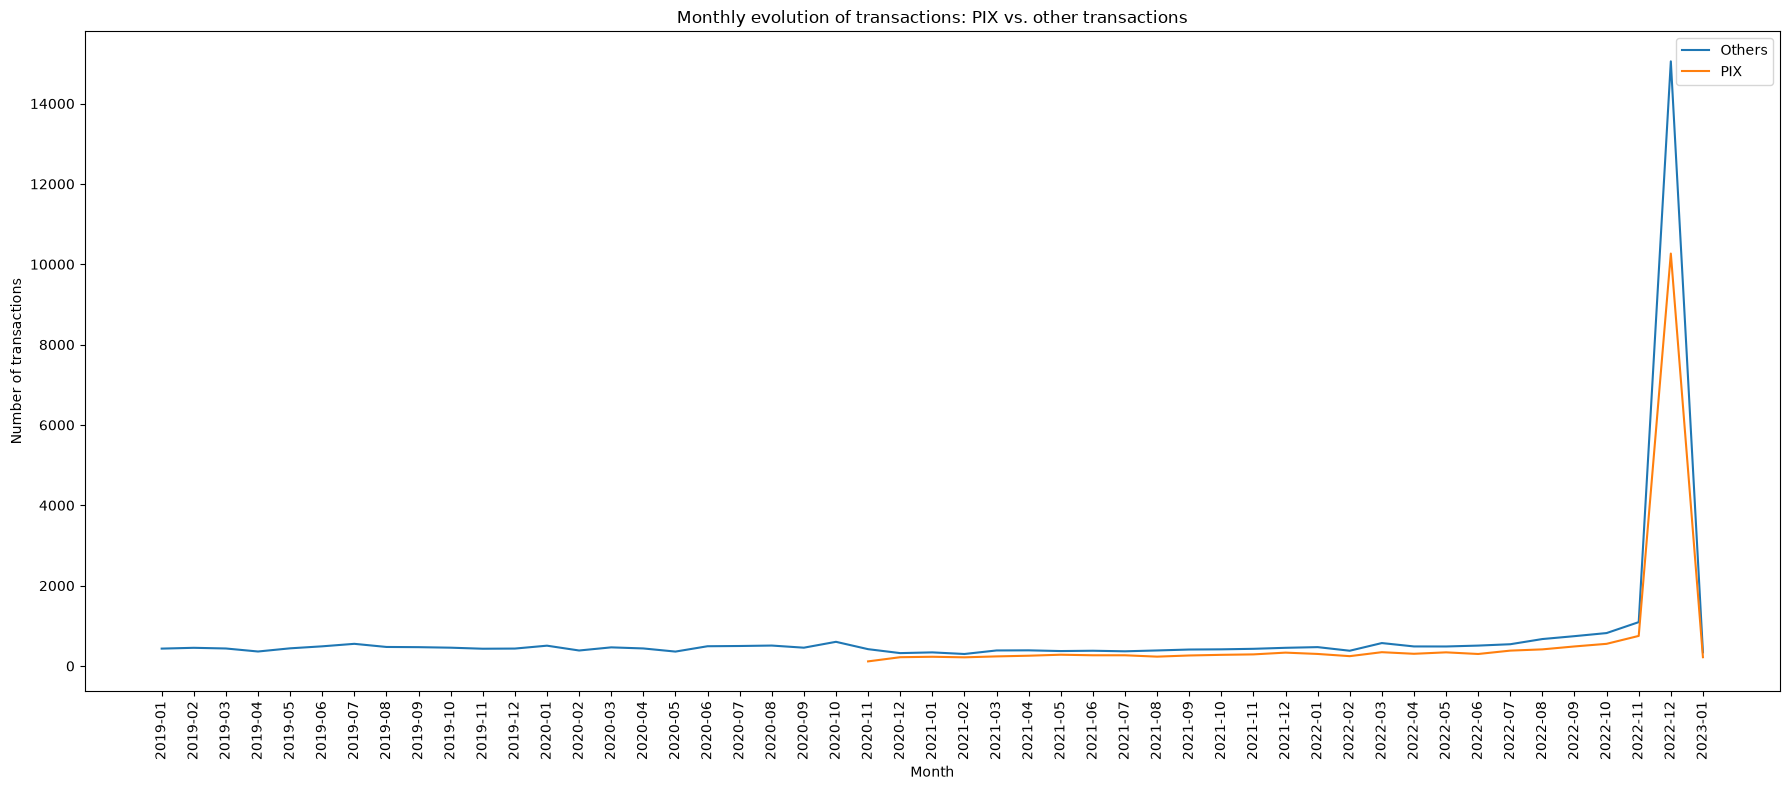

In [80]:
#Análise gráfica da evolução mensal por tipo de transação dando ênfase no PIX
plt.figure(figsize=(18, 8))
for transaction_group  in pix_evolution["transaction_group"].unique():
    group_data: pd.DataFrame = (
        pix_evolution[
            pix_evolution["transaction_group"] == transaction_group 
        ]
    )

    group_data: pd.DataFrame = (
        pix_evolution[
            (pix_evolution["transaction_group"] == transaction_group )
            & (pix_evolution["transaction_month"] >= "2019-01")
        ]
    )

    plt.plot(
        group_data["transaction_month"].astype(str),
        group_data["transaction_count"],
        label=transaction_group 
    )

plt.xlabel("Month")
plt.ylabel("Number of transactions")
plt.title("Monthly evolution of transactions: PIX vs. other transactions")


plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [81]:
#Observações:
    #A análise temporal indica a introdução das transações PIX a partir de 11-2020, 
    #com crescimento e manutenção de um volume relevante de operações ao longo do período analisado
    #Embora o PIX permaneça abaixo do conjunto das demais modalidades, sua participação torna-se expressiva quando considerada individualmente

    #No pico transacional de 12-2022, foram registradas 10267 operações PIX, 
    #correspondendo a aproximadamente 40,6% das 25319 transações realizadas no mês. As demais modalidades, somadas, representaram 15052 operações

    #O resultado sugere que o PIX passou a representar uma parcela importante da atividade transacional do BanVic nesse periodo
    #Entretanto, os dados analisados não permitem atribuir o pico de dezembro exclusivamente à adoção do PIX, 
    #sendo necessário considerar também o comportamento das demais modalidades

### Credit proposal analyses


#### Insight - Credit proposal trend & status

In [82]:
#Será analisado:
    #Volume de propostas por ano
    #Distribuição por status
    #Taxa de aprovação por ano
    #Valor médio das propostas
    #Taxa de juros média por status

#Função que analisa a quantidade de propostas de crédito por ano e status
credit_proposals_by_status = analytic.analyze_credit_proposals_by_status(
    new_datasets["propostas_credito"]
)

display(credit_proposals_by_status)

,proposal_year,status_proposta,proposal_count
3,2010,Validação documentos,44
1,2010,Em análise,41
0,2010,Aprovada,36
2,2010,Enviada,29
5,2011,Em análise,43
4,2011,Aprovada,42
7,2011,Validação documentos,41
6,2011,Enviada,38
10,2012,Enviada,49
8,2012,Aprovada,41


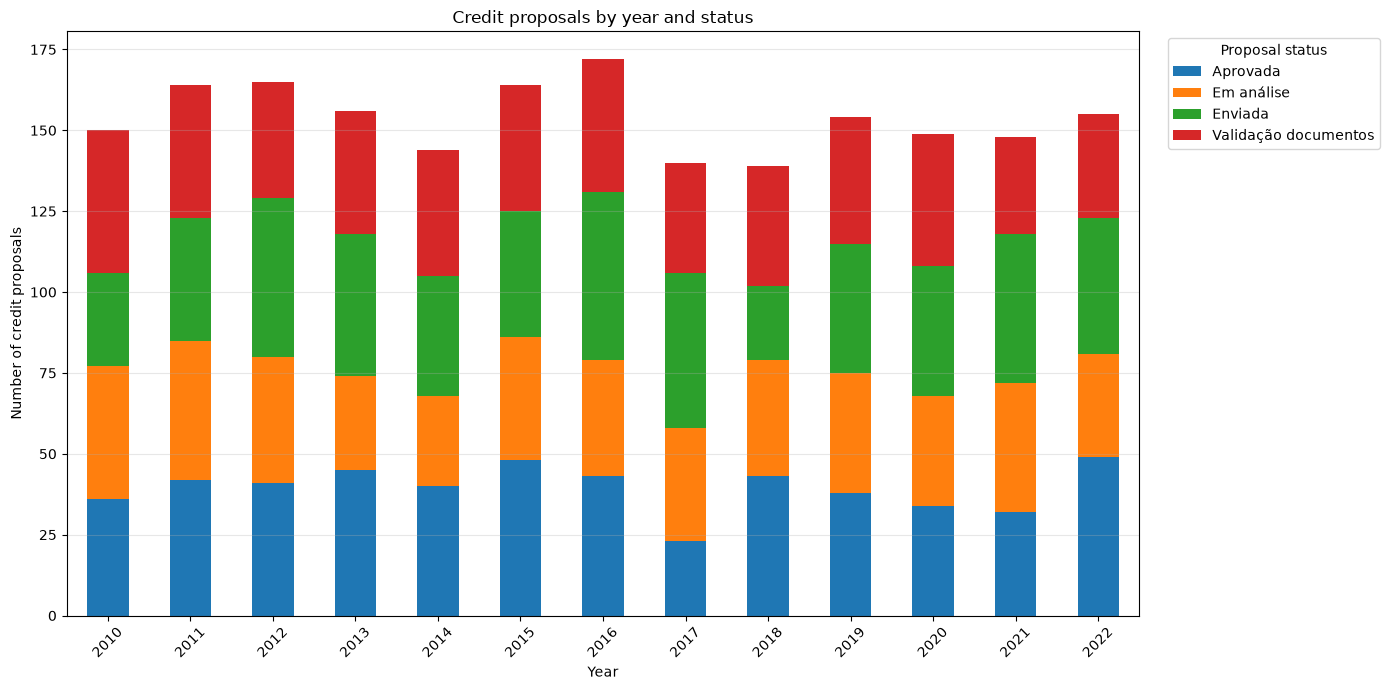

In [83]:
#Analise grafica da quantidade anual de propostas de crédito
proposal_data = (
        credit_proposals_by_status
        .pivot(
            index="proposal_year",
            columns="status_proposta",
            values="proposal_count"
        )
        .fillna(0)
        .sort_index()
    )

ax = proposal_data.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

ax.set_xlabel("Year")
ax.set_ylabel("Number of credit proposals")
ax.set_title("Credit proposals by year and status")
ax.legend(
    title="Proposal status",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [84]:
#Observações:
    #Por ano, o gráfico não entrega um insight muito forte. O volume é relativamente estável e os status ficam distribuídos de maneira parecida
    #Mas a tabela traz um ponto interessante: o status “Aprovada” varia em relação aos demais, principalmente em alguns anos
    #Porém de maneira geral, a distribuição das propostas de crédito entre os diferentes status é notavelmente uniforme ao longo do período analisado, 
    #com cada etapa representando, de forma consistente, um número semelhante de propostas
    #Esse padrão não reflete a estrutura de funil esperada em um processo de solicitação de crédito, 
    #na qual o número de propostas deveria diminuir progressivamente à medida que avançam da submissão e validação de documentos para a análise e aprovação
    #(Enviada -> Validação de documentos -> Em análise -> Aprovada)

#Recomendação:
    #Analisar qual é a taxa de aprovação das propostas de crédito e como ela varia ao longo do tempo

In [85]:
#Função que calcula a taxa anual de aprovação das propostas de crédito
approval_rate_df = analytic.analyze_credit_approval_rate(
    credit_proposals_by_status
)

display(approval_rate_df)

,proposal_year,total_proposals,approved_proposals,approval_rate
0,2010,150,36,24.000000
1,2011,164,42,25.609756
2,2012,165,41,24.848485
3,2013,156,45,28.846154
4,2014,144,40,27.777778
5,2015,164,48,29.268293
6,2016,172,43,25.000000
7,2017,140,23,16.428571
8,2018,139,43,30.935252
9,2019,154,38,24.675325


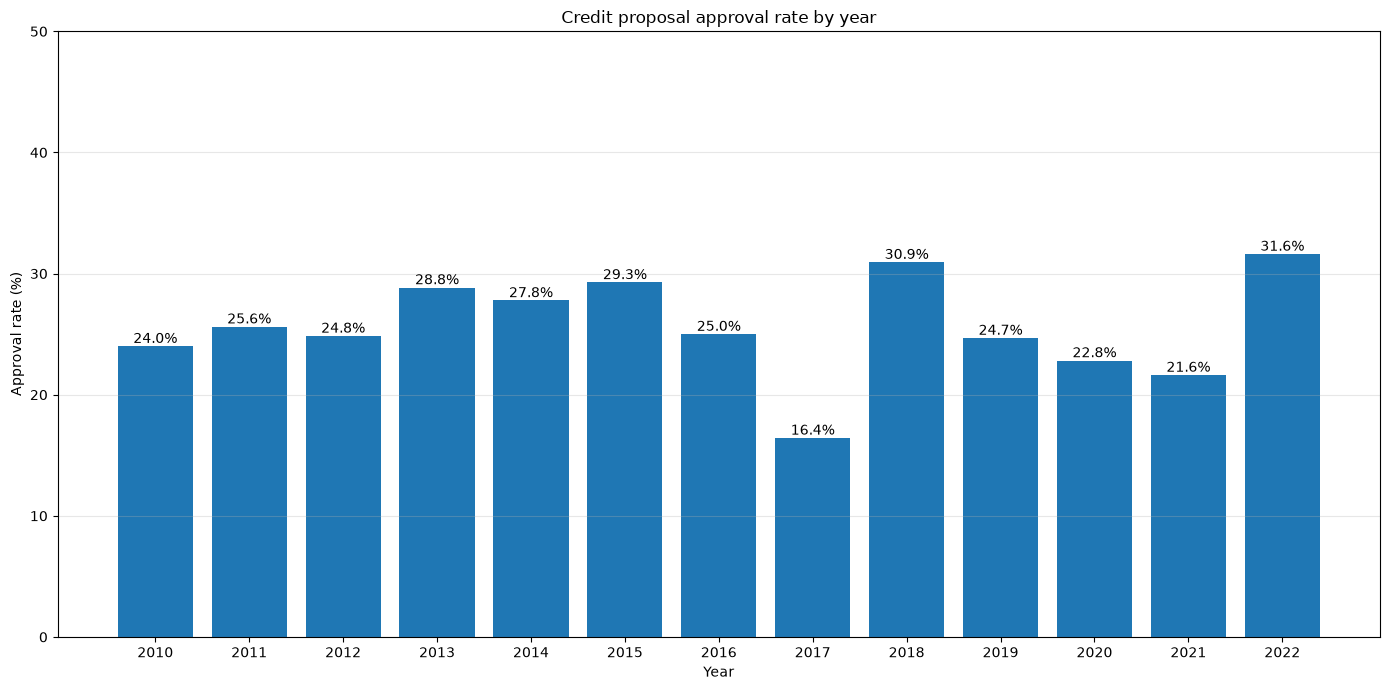

In [86]:
#Analise grafica da taxa anual de aprovação das propostas de crédito
plt.figure(figsize=(14, 7))

bars = plt.bar(
    approval_rate_df["proposal_year"],
    approval_rate_df["approval_rate"]
)

plt.xlabel("Year")
plt.ylabel("Approval rate (%)")
plt.title("Credit proposal approval rate by year")
plt.xticks(approval_rate_df["proposal_year"])
plt.ylim(0, 50)
plt.grid(axis="y", alpha=0.3)

for bar, rate in zip(
    bars,
    approval_rate_df["approval_rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [87]:
#Observações:
    #2017: queda para apenas 16,4%, a menor taxa de todo o período
    #2018: recuperação forte para 30,9%
    #2022: nova alta, chegando a 31,6%, a maior taxa observada
    #Entre 2020 e 2021, houve queda de 22,8% para 21,6%
    #Em 2022, a aprovação aumentou 10,0 pontos percentuais em relação a 2021

In [88]:
#Função que calcula o valor médio das propostas e a taxa de juros média, segmentados por ano e status da proposta
credit_proposal_analysis = analytic.analyze_credit_proposal_values(
    new_datasets["propostas_credito"]
)

display(credit_proposal_analysis)

,proposal_year,status_proposta,proposal_count,average_proposal_value,average_monthly_interest_rate
0,2010,Aprovada,36,93238.173890,0.017406
1,2010,Em análise,41,96385.852316,0.016049
2,2010,Enviada,29,100255.484919,0.017090
3,2010,Validação documentos,44,73001.350172,0.016007
4,2011,Aprovada,42,94787.590944,0.016350
5,2011,Em análise,43,81534.759177,0.016672
6,2011,Enviada,38,102793.723898,0.015337
7,2011,Validação documentos,41,83435.938306,0.015876
8,2012,Aprovada,41,96135.662454,0.016124
9,2012,Em análise,39,93737.953676,0.018372


In [89]:
#Observações:
    #As propostas de crédito apresentam um perfil bastante uniforme em todos os status
    #Os valores médios das propostas variam de R$ 81 mil a R$ 86 mil, enquanto as taxas de juros mensais médias situam-se entre 1,64% e 1,70%
    #Não foi identificada uma relação forte entre o valor da proposta, a taxa de juros e o status da proposta, 
    #o que sugere que outros fatores não presentes no conjunto de dados podem influenciar os resultados de aprovação

### EDA conclusion

In [ ]:
#Observações principais:
    #Datasets originais dispostos em arquivos CSVs representam um recorte do periodo de 01-2010 até de 01-2023 da BanVic
    #Todas as contas desse recorte de datasets são do tipo PF

#Conclusão:
    #A análise exploratória identificou padrões relevantes relacionados à atividade
    #dos clientes, ao comportamento transacional, à adoção digital e às propostas
    #de crédito. Também foram realizadas comparações entre a evolução das novas
    #agências digitais e a base já existente de agências físicas.
    
    #Desde a introdução das agências digitais em 2015, o número de contas associadas
    #a esse canal cresceu de forma consistente, atingindo um total acumulado de
    #460 contas em 2022. Embora as agências físicas ainda apresentassem uma base
    #acumulada maior, com 539 contas, a diferença diminuiu de 188 contas em 2015
    #para 79 em 2022, indicando uma adoção progressiva do canal digital e uma
    #adaptação gradual dos clientes aos novos canais bancários.
    
    #O início do EDA dos clientes também considerou a anomalia identificada
    #anteriormente na etapa de Data Quality, referente à conta 528, que não possui
    #um cliente correspondente cadastrado. O registro não foi removido nem
    #modificado, sendo mantido no conjunto de dados e sinalizado por meio de uma
    #nova coluna de identificação de anomalia.
    
    #A atividade dos clientes apresentou queda até 2020, atingindo 58,7%, seguida
    #de recuperação para 78,4% em 2022. A aquisição de novos clientes apresentou
    #variações ao longo do período analisado.
    
    #A análise de churn/inatividade apresentou uma redução relevante nos últimos
    #anos completos analisados. A taxa de clientes sem transações caiu de 41,3%
    #em 2020 para 33,8% em 2021 e 21,6% em 2022, representando uma redução de
    #aproximadamente 19,7 p.p. entre 2020 e 2022. Esse comportamento
    #acompanha a recuperação observada na atividade dos clientes e representa um
    #indicador relevante para o acompanhamento do engajamento e retenção da base.

    #O comportamento transacional apresentou um pico excepcional em dezembro de
    #2022, com 80,7% das transações do mês concentradas nos dias 29 e 30. Esse
    #comportamento exige cautela na utilização do período como referência para
    #análises de tendência, uma vez que pode representar um comportamento atípico
    #ou uma possível inconsistência na origem dos dados. Compras no crédito e débito
    #representaram 59,2% das transações, enquanto o PIX respondeu por 25,5%,
    #demonstrando sua relevância no ecossistema transacional do banco e na adoção
    #de novos meios digitais.
    
    #Nas propostas de crédito, a taxa de aprovação atingiu 31,6% em 2022. Entretanto,
    #a distribuição dos status não apresentou o comportamento esperado de um funil
    #sequencial, indicando que os status devem ser interpretados com cautela em
    #análises de conversão entre etapas.
    
    #De forma geral, o EDA destaca **atividade e retenção dos clientes, comportamento
    #transacional, adoção digital e conversão de crédito** como dimensões relevantes
    #para a análise comercial. A etapa também permitiu identificar padrões atípicos,
    #tendências de churn/inatividade e limitações nos dados que devem ser considerados
    #nas análises e recomendações posteriores.

#Tratamento de dados:
    #Zona de quarentena -> Será criada uma coluna no dataset contas para identificar com boolenano se um ano pode ser tratado como anomalia ou não e ser segregado sem necessidade de ser deletado

#Insights definidos:
    #Digital x Phisical branches
    #New customers per year
    #Active vs. Inactive customers
    #Churn rate
    #Average transaction value
    #Transactions types - Overview
    #Transactions evolution - Overview
    #Transactions evolution - Digital branch adoption
    #Transactions evolution - PIX adoption
    #Credit proposal trend funnel

#Recomendação final:
    #Criar uma seção de KPI summary para copilar quais indicadores devem ser utilizados no dashboard

## KPIs Summary

### Table

| Área                 | KPI / Análise                                         | Objetivo                                                          |
| -------------------- | ----------------------------------------------------- | ----------------------------------------------------------------- |
| Digital Adoption     | **Cumulative Digital vs. Physical Branches per year** | Acompanhar a adesão cumulativa anual dos canais ao longo do tempo |
| Digital Adoption     | **Transaction Evolution - PIX Adoption**              | Acompanhar a evolução e participação do PIX                       |
| Customer Acquisition | **New Customers per Year**                            | Monitorar a entrada de novos clientes                             |
| Customer Engagement  | **Active vs. Inactive Customers per year**            | Avaliar o nível de atividade da base por ano                      |
| Customer Retention   | **Churn Rate**                                        | Monitorar perda/inatividade de clientes ao longo do tempo         |
| Transactions         | **Average transaction value**                         | Acompanhar a média do valor de transações                         |
| Transactions         | **Transaction Evolution - Overview**                  | Acompanhar a evolução do numero de transações ao longo do tempo   |
| Credit               | **Credit Proposal Trend & Funnel**                    | Avaliar o volume, status e aprovação das propostas                |

## Mockup

#Mockup pré-definido

![image.png](../img/premockup.png)

#Mockup gerado com Figma + IA

![image.png](../img/mockup.png)

## Dataset rows quarantine

In [91]:
#Seção criada a partr da análise de que a conta 528 foi considerada anômala e precisaria ser segregada
#Aqui é possivel definir outras contas para segregar
anomalous_account_ids: list[int] = [528]

#Função que irá gerar uma coluna de flag para identificar contas anômalas e futuramente separa-las no power BI
new_datasets["contas"] = analytic.flag_anomalous_accounts(
    new_datasets["contas"],
    anomalous_account_ids
)

## New dataset generated

In [92]:
#Chamando função principal para gerar os novos datasets CSVs já tratados a partir dos arquivos CSVs antigos
func.save_csv_files(new_datasets, NEW_DATASET_DIR)